# DBSCAN – Unusual Customer Identification

## Problem Statement

**Can we identify unusual customers based on their service usage?**

### Objective
Use **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** to identify groups of customers with similar service usage and detect unusual customers as noise points.

This notebook focuses only on DBSCAN.


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
file_path = r"C:\Users\hp\Desktop\calibo\Supervised_Learning_Messy_Customer_Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (184, 13)


## Step 3: View the Dataset

In [3]:
display(df.head())


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


## Step 4: Understand the Dataset

Check:
- Shape
- Columns
- Data types
- Statistical summary


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary:")
display(df.describe(include="all").T)


Rows: 184
Columns: 13

Column names:
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']

Data types:
Customer_ID                  str
Age                      float64
Annual_Income                str
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,184,180,CUST-1043,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,176.0,NaN,NaN,NaN,36.164773,12.865951,-5.0,29.0,36.0,41.0,145.0
Annual_Income,173,156,76600.0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure_Months,177.0,NaN,NaN,NaN,39.39548,21.545185,1.0,25.0,38.0,55.0,150.0
Monthly_Charges,178.0,NaN,NaN,NaN,80.205899,74.17937,0.0,57.885,73.565,90.28,999.0
Support_Calls_Last_3M,179.0,NaN,NaN,NaN,3.217877,2.577455,0.0,2.0,3.0,4.0,30.0
Data_Usage_GB,178.0,NaN,NaN,NaN,17.80618,9.245516,-10.0,11.6,18.2,24.2,44.0
Satisfaction_Score,178.0,NaN,NaN,NaN,5.803371,2.947869,1.0,4.0,6.0,8.0,15.0
Contract_Type,184,8,Monthly,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,184,9,Bank Transfer,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 5: Check Missing Values

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])


Missing values in each column:
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
dtype: int64


## Step 6: Check Duplicate Records

In [6]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)


Duplicate rows: 4


## Step 7: Remove Duplicate Records

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (180, 13)


## Step 8: Correlation Heatmap

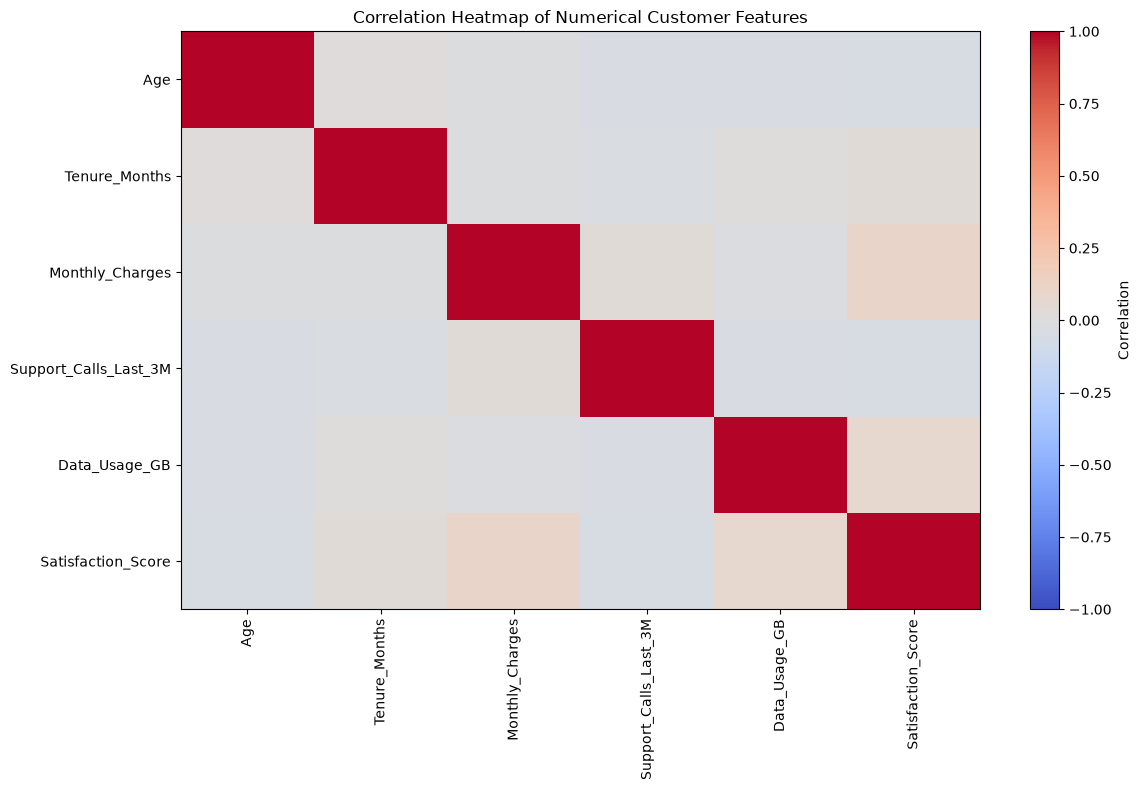

In [8]:
# Correlation heatmap for numerical features

numerical_df = df.select_dtypes(include=np.number)

if numerical_df.shape[1] >= 2:
    correlation_matrix = numerical_df.corr()

    plt.figure(figsize=(12, 8))
    plt.imshow(
        correlation_matrix,
        cmap="coolwarm",
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=90
    )

    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns
    )

    plt.title("Correlation Heatmap of Numerical Customer Features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical features for a correlation heatmap.")


## Step 9: Box Plots

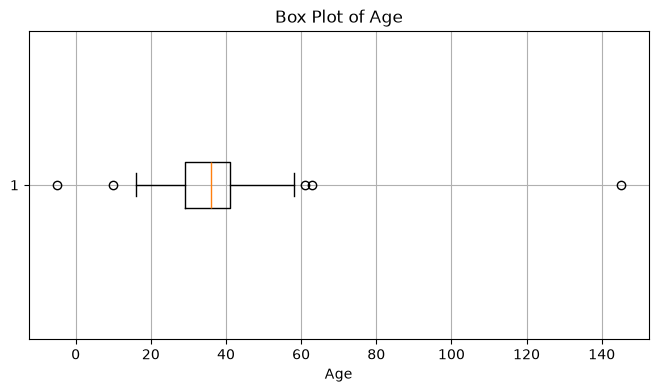

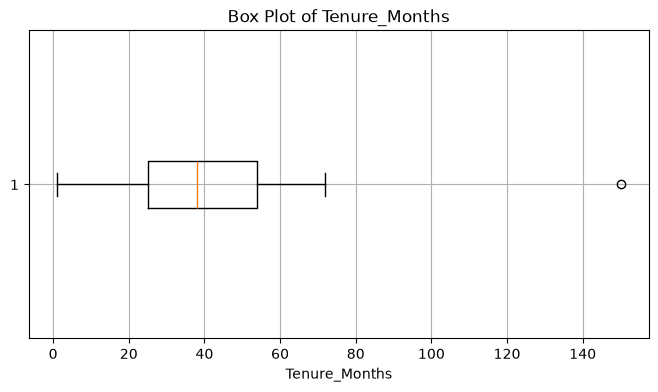

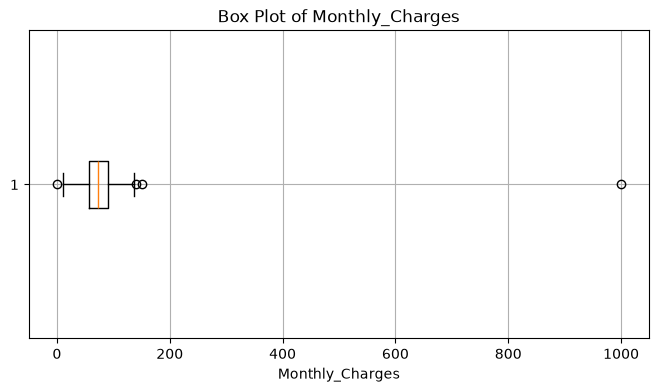

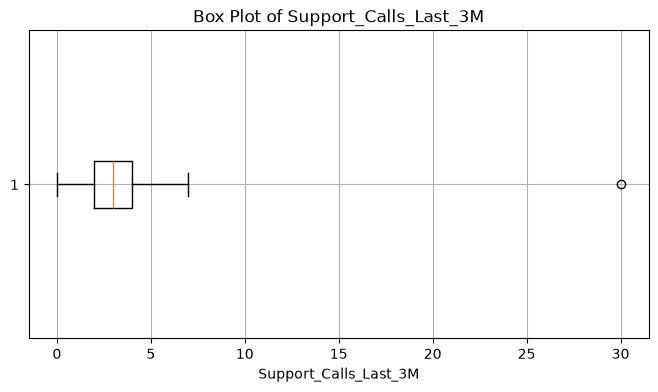

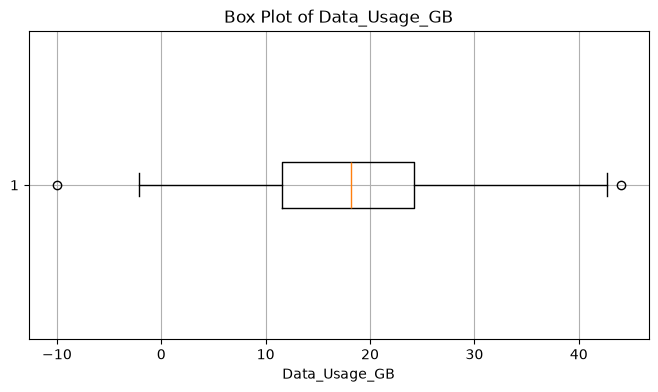

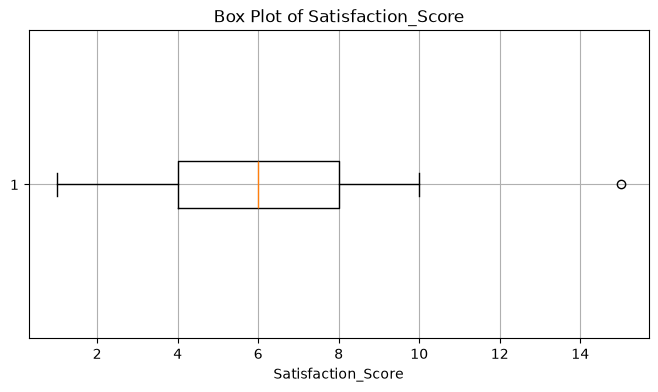

In [9]:
# Box plots for numerical features

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numerical_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.xlabel(column)
    plt.title(f"Box Plot of {column}")
    plt.grid(True)

    plt.show()


## Step 10: Detect Outliers using IQR

The IQR method is used to identify extreme values in numerical features.

- Lower Bound = Q1 − 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Important: DBSCAN is designed to detect unusual observations itself. Therefore, we do not delete all IQR outliers before DBSCAN.


In [10]:
# IQR outlier summary

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": int(outlier_mask.sum())
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.round(2))


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,29.00,41.00,12.00,11.0,59.00,5
1,Tenure_Months,25.00,54.00,29.00,-18.5,97.50,1
2,Monthly_Charges,57.46,90.03,32.57,8.6,138.89,4
3,Support_Calls_Last_3M,2.00,4.00,2.00,-1.0,7.00,1
4,Data_Usage_GB,11.60,24.20,12.60,-7.3,43.10,2
5,Satisfaction_Score,4.00,8.00,4.00,-2.0,14.00,1


## Step 11: Handle Extreme Values for DBSCAN

Because the purpose of this problem is to identify unusual customers, extreme observations should not simply be deleted.

Instead, the numerical features are kept and later **StandardScaler** is used so that large-scale variables do not dominate the distance calculation.


In [11]:
df_model = df.copy()

print("All customer records are retained for DBSCAN.")
print("Rows available for clustering:", len(df_model))


All customer records are retained for DBSCAN.
Rows available for clustering: 180


## Step 12: Remove Unnecessary Columns

- `Customer_ID` is an identifier and is not a usage feature.
- `Churn` is a target/label and is not used in unsupervised learning.


In [12]:
columns_to_drop = []

if "Customer_ID" in df_model.columns:
    columns_to_drop.append("Customer_ID")

if "Churn" in df_model.columns:
    columns_to_drop.append("Churn")

df_model = df_model.drop(
    columns=columns_to_drop,
    errors="ignore"
).copy()

print("Removed columns:", columns_to_drop)
print("Shape after removing unnecessary columns:", df_model.shape)


Removed columns: ['Customer_ID', 'Churn']
Shape after removing unnecessary columns: (180, 11)


## Step 13: Convert Annual Income to Numeric

In [13]:
if "Annual_Income" in df_model.columns:
    df_model["Annual_Income"] = (
        df_model["Annual_Income"]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )

    df_model["Annual_Income"] = pd.to_numeric(
        df_model["Annual_Income"],
        errors="coerce"
    )

print(df_model.dtypes)


Age                      float64
Annual_Income            Float64
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
dtype: object


## Step 14: Identify Numerical and Categorical Features

In [14]:
numerical_features = df_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = df_model.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']


## Step 15: Handle Missing Values

In [15]:
# Fill numerical missing values with median
for column in numerical_features:
    df_model[column] = df_model[column].fillna(
        df_model[column].median()
    )

# Fill categorical missing values with mode
for column in categorical_features:
    mode_value = df_model[column].mode(dropna=True)

    if not mode_value.empty:
        df_model[column] = df_model[column].fillna(
            mode_value.iloc[0]
        )

print(
    "Total missing values after handling:",
    int(df_model.isnull().sum().sum())
)


Total missing values after handling: 0


## Step 16: Feature Selection

For identifying unusual customers based on service usage, the main usage-related numerical features are selected when they are available.


In [16]:
preferred_usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months",
    "Age",
    "Satisfaction_Score",
    "Annual_Income"
]

selected_features = [
    column
    for column in preferred_usage_features
    if column in df_model.columns
]

# Safety fallback: use all available numerical features
if len(selected_features) == 0:
    selected_features = numerical_features.copy()

print("Selected features:")
print(selected_features)


Selected features:
['Monthly_Charges', 'Data_Usage_GB', 'Support_Calls_Last_3M', 'Tenure_Months', 'Age', 'Satisfaction_Score', 'Annual_Income']


## Step 17: Prepare Data for Encoding

In [17]:
model_input = df_model[
    selected_features + categorical_features
].copy()

print("Shape before encoding:", model_input.shape)


Shape before encoding: (180, 11)


## Step 18: Encode Categorical Features

In [18]:
X = pd.get_dummies(
    model_input,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X.shape)

print("\nRemaining categorical columns:")
print(
    X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)


Shape after encoding: (180, 34)

Remaining categorical columns:
[]


## Step 19: Final Data Cleaning Before Scaling

In [19]:
# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill any remaining missing values
for column in X.columns:
    if X[column].isnull().any():
        median_value = X[column].median()

        if pd.isna(median_value):
            X[column] = X[column].fillna(0)
        else:
            X[column] = X[column].fillna(median_value)

print("Total missing values:", int(X.isnull().sum().sum()))
print(
    "Remaining categorical columns:",
    X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)


Total missing values: 0
Remaining categorical columns: []


## Step 20: Feature Scaling

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)


Feature scaling completed.
Scaled data shape: (180, 34)


## Step 21: Final Data Validation

In [21]:
print("Shape:", X_scaled.shape)
print("Missing values:", int(np.isnan(X_scaled).sum()))
print("Infinite values:", int(np.isinf(X_scaled).sum()))


Shape: (180, 34)
Missing values: 0
Infinite values: 0


## Step 22: Choose DBSCAN Parameters

DBSCAN mainly depends on:
- `eps`: maximum distance for neighboring points
- `min_samples`: minimum number of points required to form a dense region

A k-distance plot is used to help choose `eps`.


In [22]:
# Select a safe min_samples value

n_samples = X_scaled.shape[0]

min_samples = max(
    5,
    min(10, n_samples - 1)
)

print("Selected min_samples:", min_samples)


Selected min_samples: 10


## Step 23: K-Distance Plot for Selecting eps

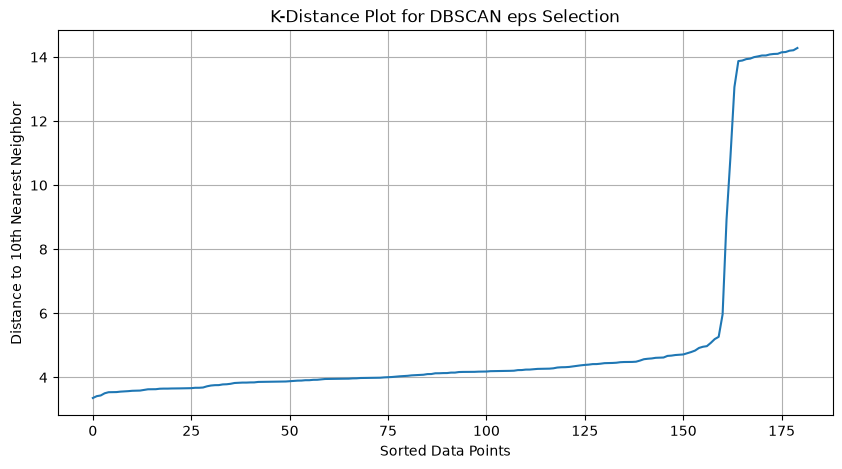

In [23]:
# Calculate distances to the kth nearest neighbor

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# Distance to the kth neighbor
k_distances = np.sort(
    distances[:, min_samples - 1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Sorted Data Points")
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbor")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.grid(True)

plt.show()


## Step 24: Set eps

The k-distance plot above can be inspected for the point where the curve begins to rise sharply.

The code below uses a data-driven candidate value from the upper part of the k-distance distribution. The resulting model is then evaluated.


In [24]:
# Data-driven initial eps value
eps = float(np.percentile(k_distances, 90))

print("Initial eps:", round(eps, 4))
print("min_samples:", min_samples)


Initial eps: 9.122
min_samples: 10


## Step 25: Train DBSCAN Model

In [25]:
dbscan_model = DBSCAN(
    eps=eps,
    min_samples=min_samples
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

print("DBSCAN model trained successfully.")


DBSCAN model trained successfully.


## Step 26: Analyze DBSCAN Results

DBSCAN uses:
- Cluster labels `0, 1, 2, ...` for dense groups
- Label `-1` for noise/unusual observations

For this problem, noise points are the customers that DBSCAN identifies as unusual based on their local density.


In [26]:
unique_labels = sorted(set(dbscan_labels))

print("Cluster labels:", unique_labels)

noise_count = int(np.sum(dbscan_labels == -1))
cluster_count = len(
    [label for label in unique_labels if label != -1]
)

print("Number of clusters:", cluster_count)
print("Number of unusual/noise customers:", noise_count)
print(
    "Percentage of unusual/noise customers:",
    round(noise_count / len(dbscan_labels) * 100, 2),
    "%"
)


Cluster labels: [np.int64(-1), np.int64(0)]
Number of clusters: 1
Number of unusual/noise customers: 18
Percentage of unusual/noise customers: 10.0 %


## Step 27: Cluster Size Summary

In [27]:
cluster_counts = pd.Series(
    dbscan_labels,
    name="Cluster"
).value_counts().sort_index()

cluster_summary = cluster_counts.to_frame(
    name="Customer_Count"
)

cluster_summary["Percentage"] = (
    cluster_summary["Customer_Count"]
    / len(dbscan_labels)
    * 100
)

display(cluster_summary.round(2))


,Customer_Count,Percentage
Cluster,,
-1,18,10.0
0,162,90.0


## Step 28: Add DBSCAN Labels to Customer Data

In [28]:
df_clustered = df_model.copy()

df_clustered["DBSCAN_Cluster"] = dbscan_labels

df_clustered["Customer_Type"] = np.where(
    df_clustered["DBSCAN_Cluster"] == -1,
    "Unusual Customer",
    "Regular Customer"
)

display(
    df_clustered[
        ["DBSCAN_Cluster", "Customer_Type"]
    ].head()
)


,DBSCAN_Cluster,Customer_Type
0,-1,Unusual Customer
1,0,Regular Customer
2,0,Regular Customer
3,0,Regular Customer
4,0,Regular Customer


## Step 29: Identify Unusual Customers

In [29]:
unusual_customers = df_clustered[
    df_clustered["DBSCAN_Cluster"] == -1
].copy()

print(
    "Number of unusual customers:",
    len(unusual_customers)
)

display(unusual_customers.head(10))


Number of unusual customers: 18


,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,DBSCAN_Cluster,Customer_Type
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,-1,Unusual Customer
35,33.0,83900.0,42.0,80.50,30.0,19.0,3.0,2 Year,Credit Card,North,Standard,-1,Unusual Customer
66,37.0,56900.0,38.0,67.10,4.0,36.4,1.0,Monthly,Credit Card,North,basic,-1,Unusual Customer
71,44.0,64400.0,17.0,115.14,3.0,8.5,4.0,2 Year,Credit Card,West,premium,-1,Unusual Customer
79,32.0,100000.0,12.0,56.23,3.0,9.8,6.0,1 Year,Debit Card,west,Premium,-1,Unusual Customer
95,37.0,9999999.0,5.0,91.79,4.0,6.4,9.0,1 Year,Bank Transfer,East,Premium,-1,Unusual Customer
102,37.0,62300.0,51.0,65.34,2.0,18.2,2.0,2-Year,Debit Card,West,Standard,-1,Unusual Customer
107,47.0,73900.0,51.0,12.71,1.0,24.2,9.0,Monthly,Bank Transfer,NORTH,Standard,-1,Unusual Customer
112,52.0,75400.0,31.0,55.51,4.0,9.4,9.0,1 year,Bank Transfer,South,Standard,-1,Unusual Customer
122,34.0,36600.0,69.0,104.15,3.0,15.8,3.0,monthly,Debit Card,East,Premium,-1,Unusual Customer


## Step 30: Evaluate DBSCAN Using Silhouette Score

The Silhouette Score is calculated only when DBSCAN produces at least two clusters and the result contains more than one label.

Noise points (`-1`) are excluded from this score because they are not regular clusters.


In [30]:
non_noise_mask = dbscan_labels != -1

regular_labels = dbscan_labels[non_noise_mask]
regular_data = X_scaled[non_noise_mask]

if (
    len(regular_data) > 1
    and len(np.unique(regular_labels)) >= 2
):
    dbscan_silhouette = silhouette_score(
        regular_data,
        regular_labels
    )

    print(
        "DBSCAN Silhouette Score (excluding noise):",
        round(dbscan_silhouette, 4)
    )
else:
    dbscan_silhouette = np.nan

    print(
        "Silhouette Score cannot be calculated because "
        "DBSCAN produced fewer than two regular clusters."
    )


Silhouette Score cannot be calculated because DBSCAN produced fewer than two regular clusters.


## Step 31: PCA for DBSCAN Visualization

In [31]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["DBSCAN_Cluster"] = dbscan_labels

print(
    "PC1 explained variance:",
    round(pca.explained_variance_ratio_[0], 4)
)

print(
    "PC2 explained variance:",
    round(pca.explained_variance_ratio_[1], 4)
)

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)


PC1 explained variance: 0.0582
PC2 explained variance: 0.0545
Total explained variance: 0.1127


## Step 32: Visualize DBSCAN Clusters and Unusual Customers

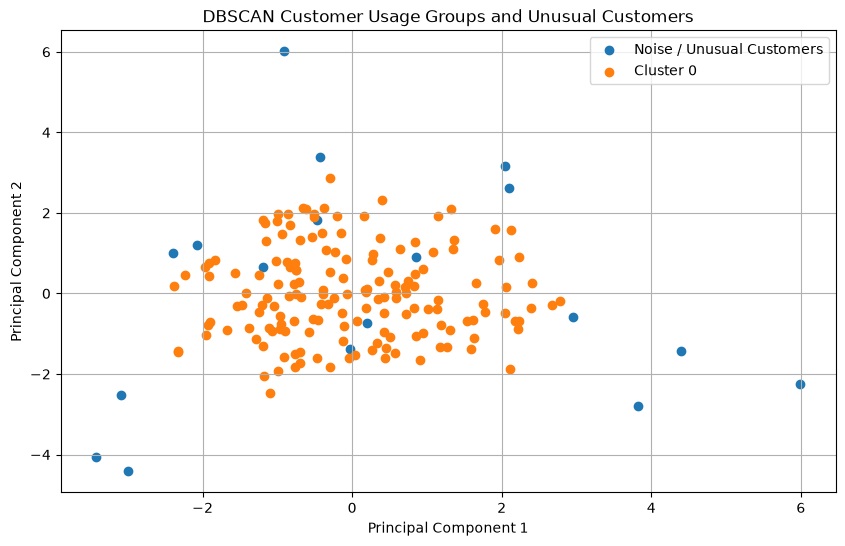

In [32]:
plt.figure(figsize=(10, 6))

for cluster in sorted(
    pca_df["DBSCAN_Cluster"].unique()
):
    cluster_data = pca_df[
        pca_df["DBSCAN_Cluster"] == cluster
    ]

    if cluster == -1:
        label = "Noise / Unusual Customers"
    else:
        label = f"Cluster {cluster}"

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=label
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "DBSCAN Customer Usage Groups and Unusual Customers"
)
plt.legend()
plt.grid(True)
plt.show()


## Step 33: Profile Regular Customer Clusters

In [33]:
usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months"
]

available_usage_features = [
    column
    for column in usage_features
    if column in df_clustered.columns
]

regular_profile = (
    df_clustered[
        df_clustered["DBSCAN_Cluster"] != -1
    ][
        available_usage_features + ["DBSCAN_Cluster"]
    ]
    .groupby("DBSCAN_Cluster")
    .mean(numeric_only=True)
)

display(regular_profile.round(2))


,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
DBSCAN_Cluster,,,,
0,75.07,17.88,3.07,39.64


## Step 34: Profile Unusual Customers

In [34]:
if len(unusual_customers) > 0:
    unusual_profile = (
        unusual_customers[
            available_usage_features
        ]
        .mean(numeric_only=True)
        .to_frame("Average_Value")
    )

    display(unusual_profile.round(2))
else:
    print("DBSCAN did not identify any unusual customers.")


,Average_Value
Monthly_Charges,120.94
Data_Usage_GB,17.25
Support_Calls_Last_3M,4.39
Tenure_Months,35.78


## Step 35: Visualize Customer Distribution

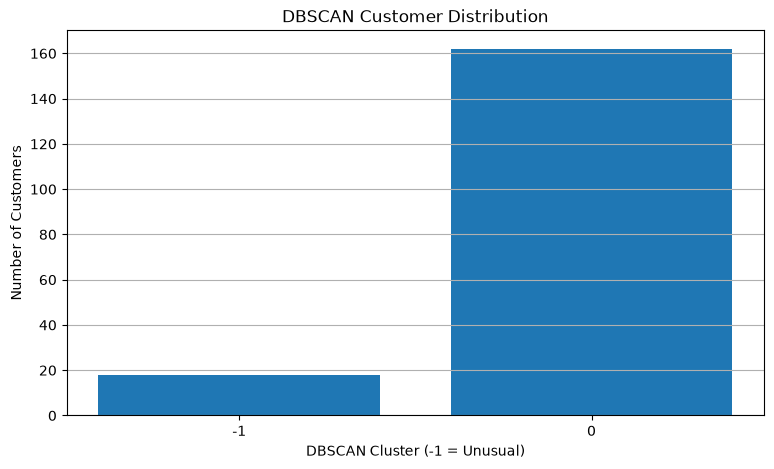

In [35]:
display_columns = cluster_summary.index.astype(str)

plt.figure(figsize=(9, 5))

plt.bar(
    display_columns,
    cluster_summary["Customer_Count"]
)

plt.xlabel("DBSCAN Cluster (-1 = Unusual)")
plt.ylabel("Number of Customers")
plt.title("DBSCAN Customer Distribution")
plt.grid(axis="y")

plt.show()


## Step 36: Final Results

In [36]:
print("=" * 65)
print("FINAL DBSCAN RESULTS")
print("=" * 65)

print("\nProblem Statement:")
print(
    "Can we identify unusual customers based on their service usage?"
)

print("\nDBSCAN Parameters:")
print("eps:", round(eps, 4))
print("min_samples:", min_samples)

print("\nNumber of Regular Clusters:", cluster_count)
print("Number of Unusual/Noise Customers:", noise_count)

print(
    "Percentage of Unusual Customers:",
    round(noise_count / len(dbscan_labels) * 100, 2),
    "%"
)

if not pd.isna(dbscan_silhouette):
    print(
        "Silhouette Score (excluding noise):",
        round(dbscan_silhouette, 4)
    )
else:
    print(
        "Silhouette Score: Not available "
        "(fewer than two regular clusters)"
    )


FINAL DBSCAN RESULTS

Problem Statement:
Can we identify unusual customers based on their service usage?

DBSCAN Parameters:
eps: 9.122
min_samples: 10

Number of Regular Clusters: 1
Number of Unusual/Noise Customers: 18
Percentage of Unusual Customers: 10.0 %
Silhouette Score: Not available (fewer than two regular clusters)


## Step 37: Conclusion

DBSCAN was used to identify customers with similar service usage patterns and detect unusual customers.

The dataset was cleaned, duplicate records were removed, numerical relationships were explored using a correlation heatmap, distributions were examined using box plots, and IQR-based outliers were identified.

Instead of deleting potential unusual customers, the observations were retained because detecting unusual behavior is the main objective of DBSCAN. Features were encoded and scaled before clustering.

DBSCAN identified dense customer groups and assigned low-density observations to the noise class (`-1`). These noise points represent customers whose service usage differs from the learned dense usage patterns.

Therefore, DBSCAN can be used to discover customer groups while simultaneously identifying potentially unusual service-usage behavior.
